<a href="https://colab.research.google.com/github/chiranmainayak/data-cleaning-and-visualization/blob/main/TASK_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Target Species  
0       0  Setosa  
1       0  Setosa  
2       0  Setosa  
3       0  Setosa  
4       0  Setosa  

Last 5 rows:
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4             

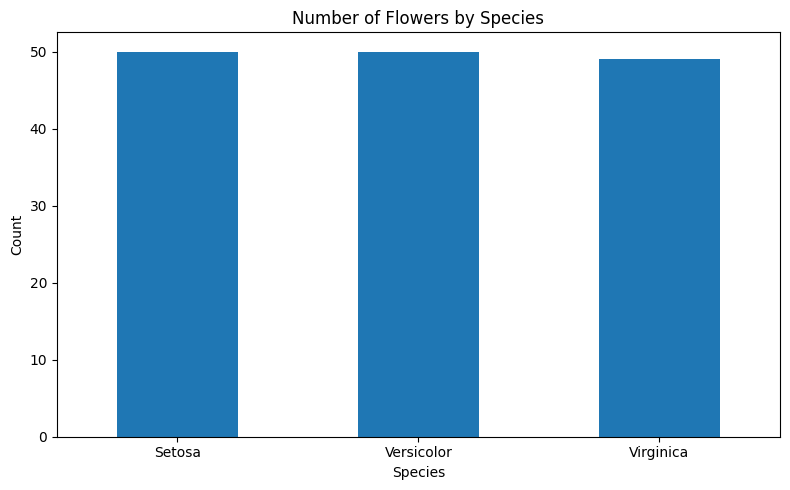

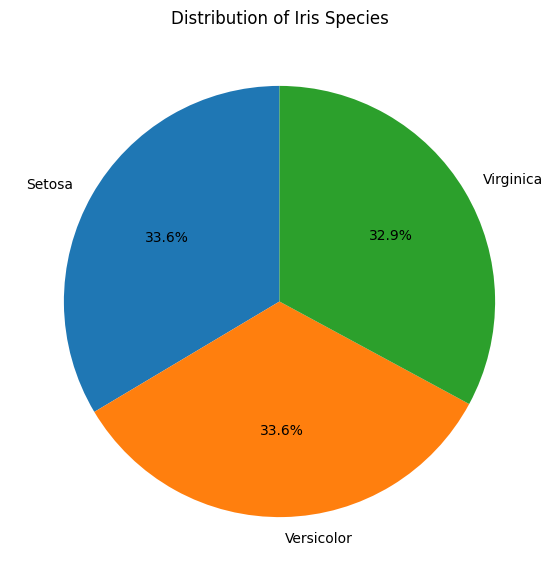

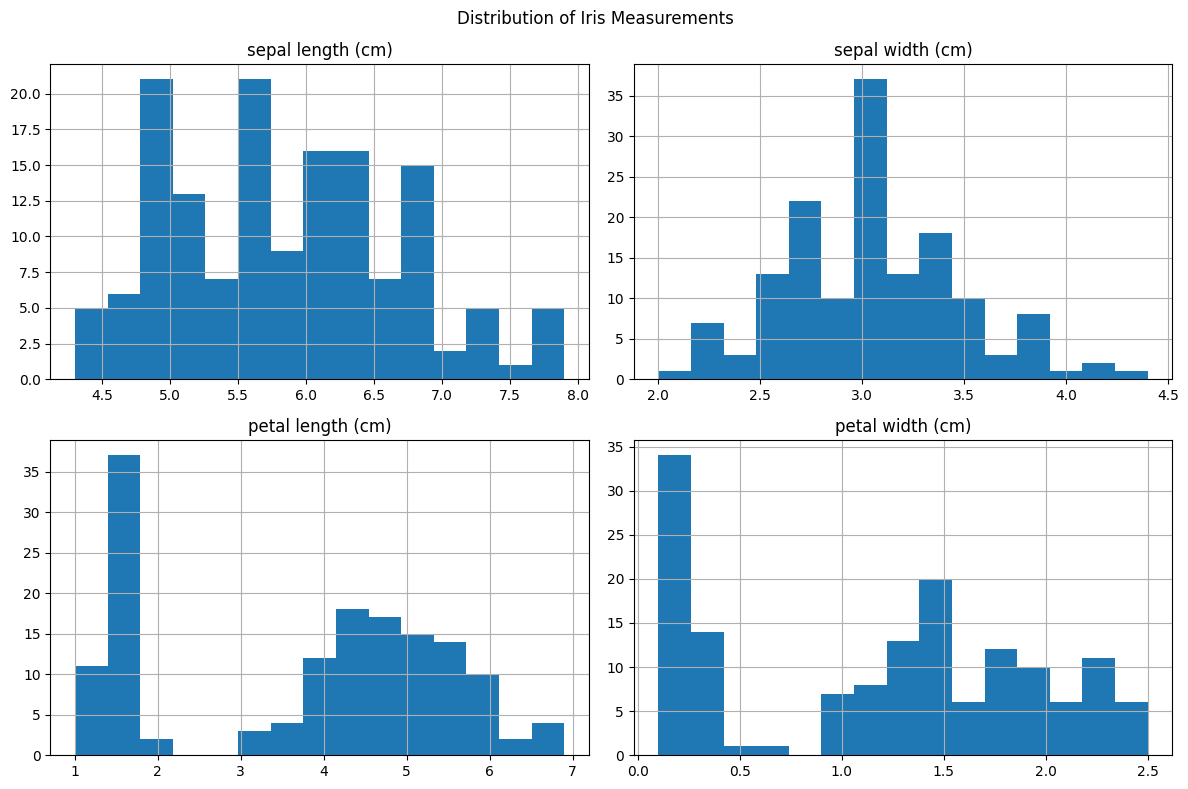

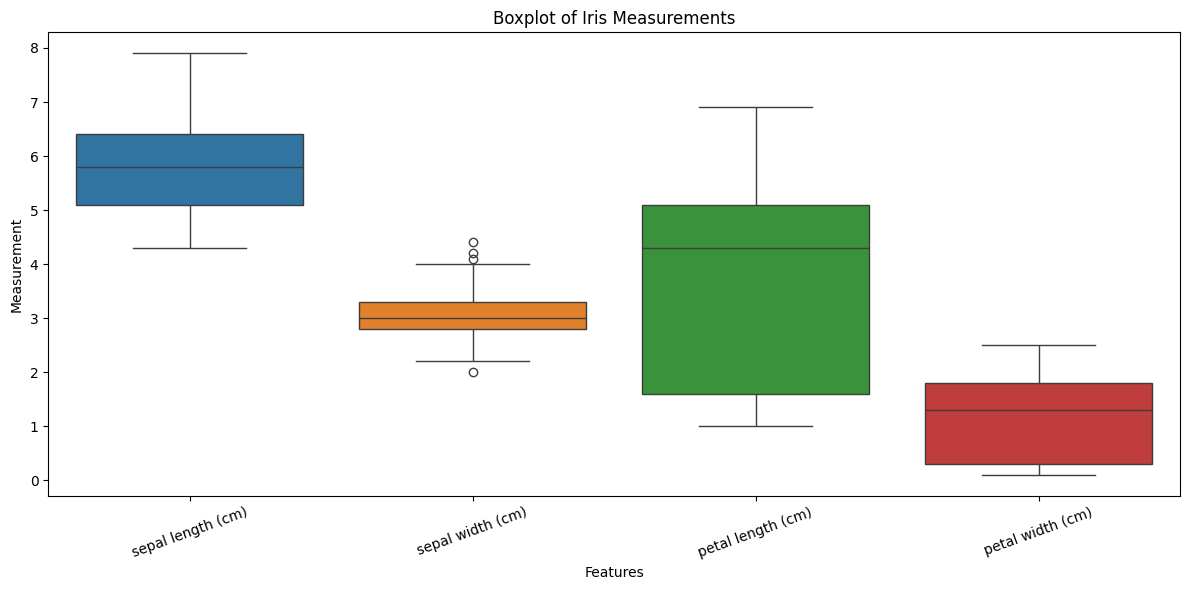

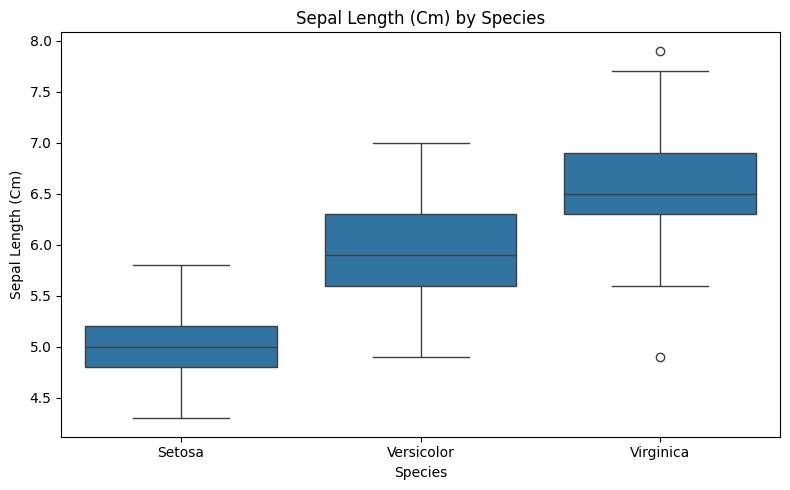

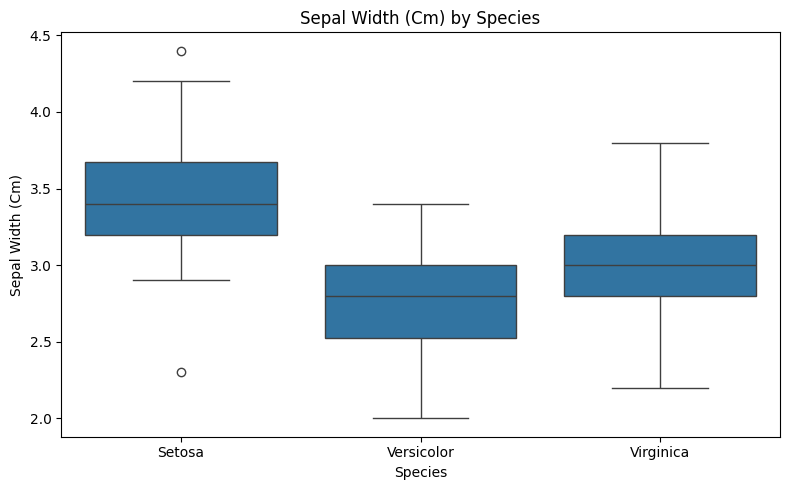

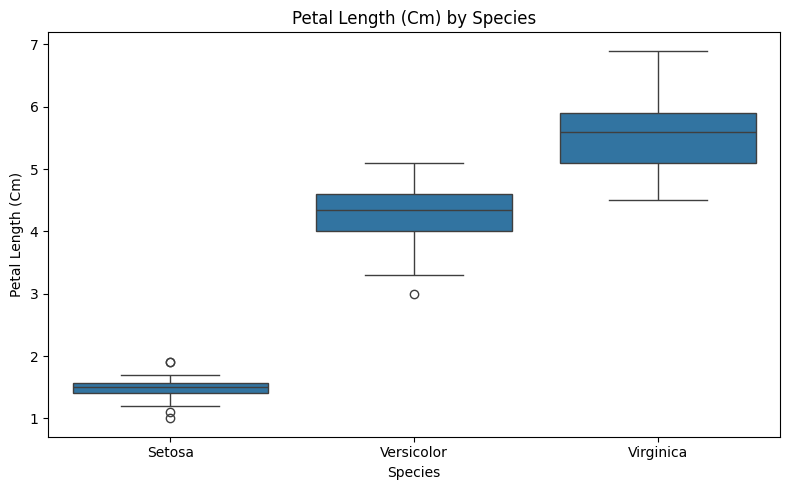

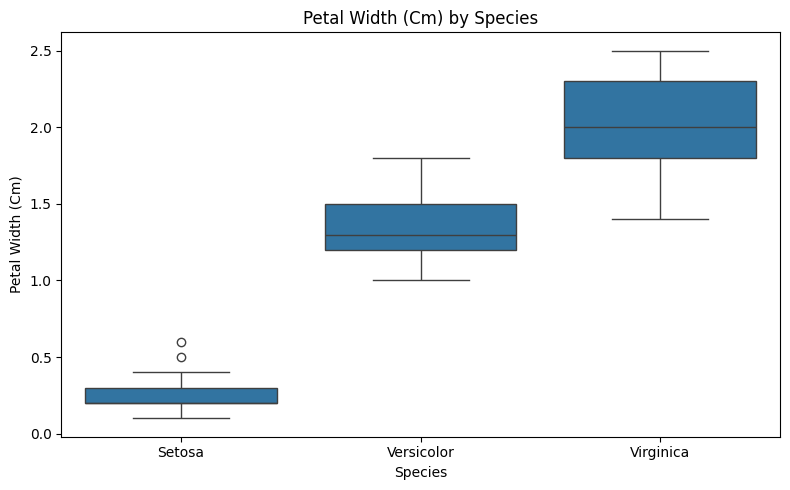

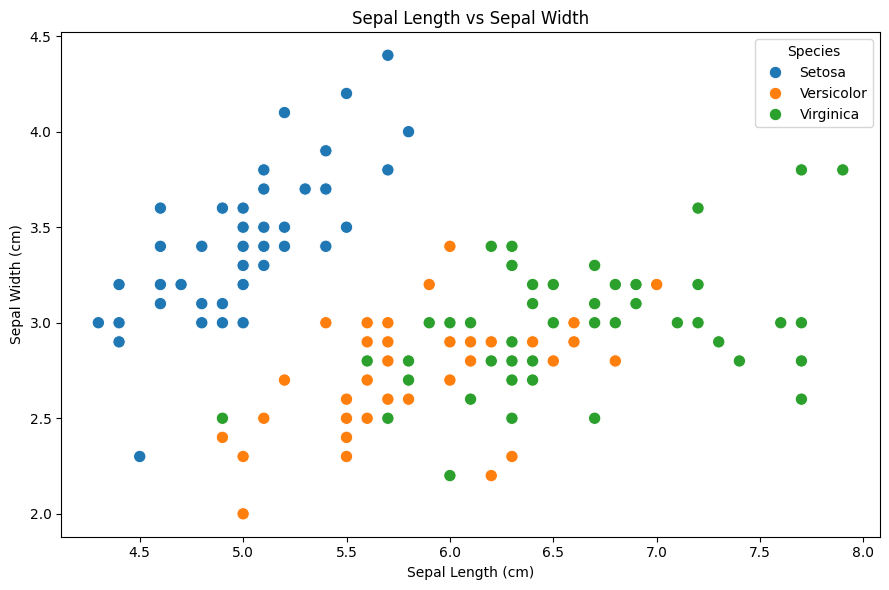

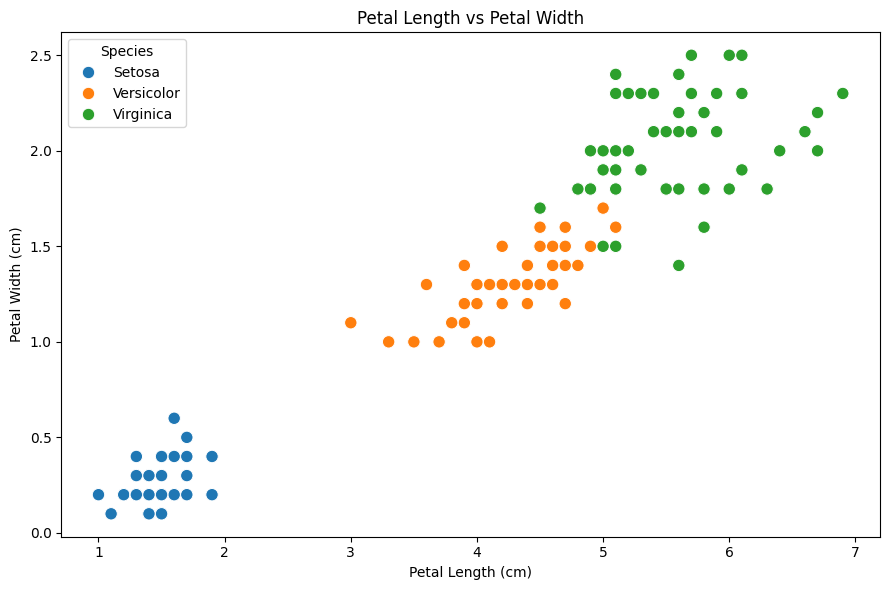

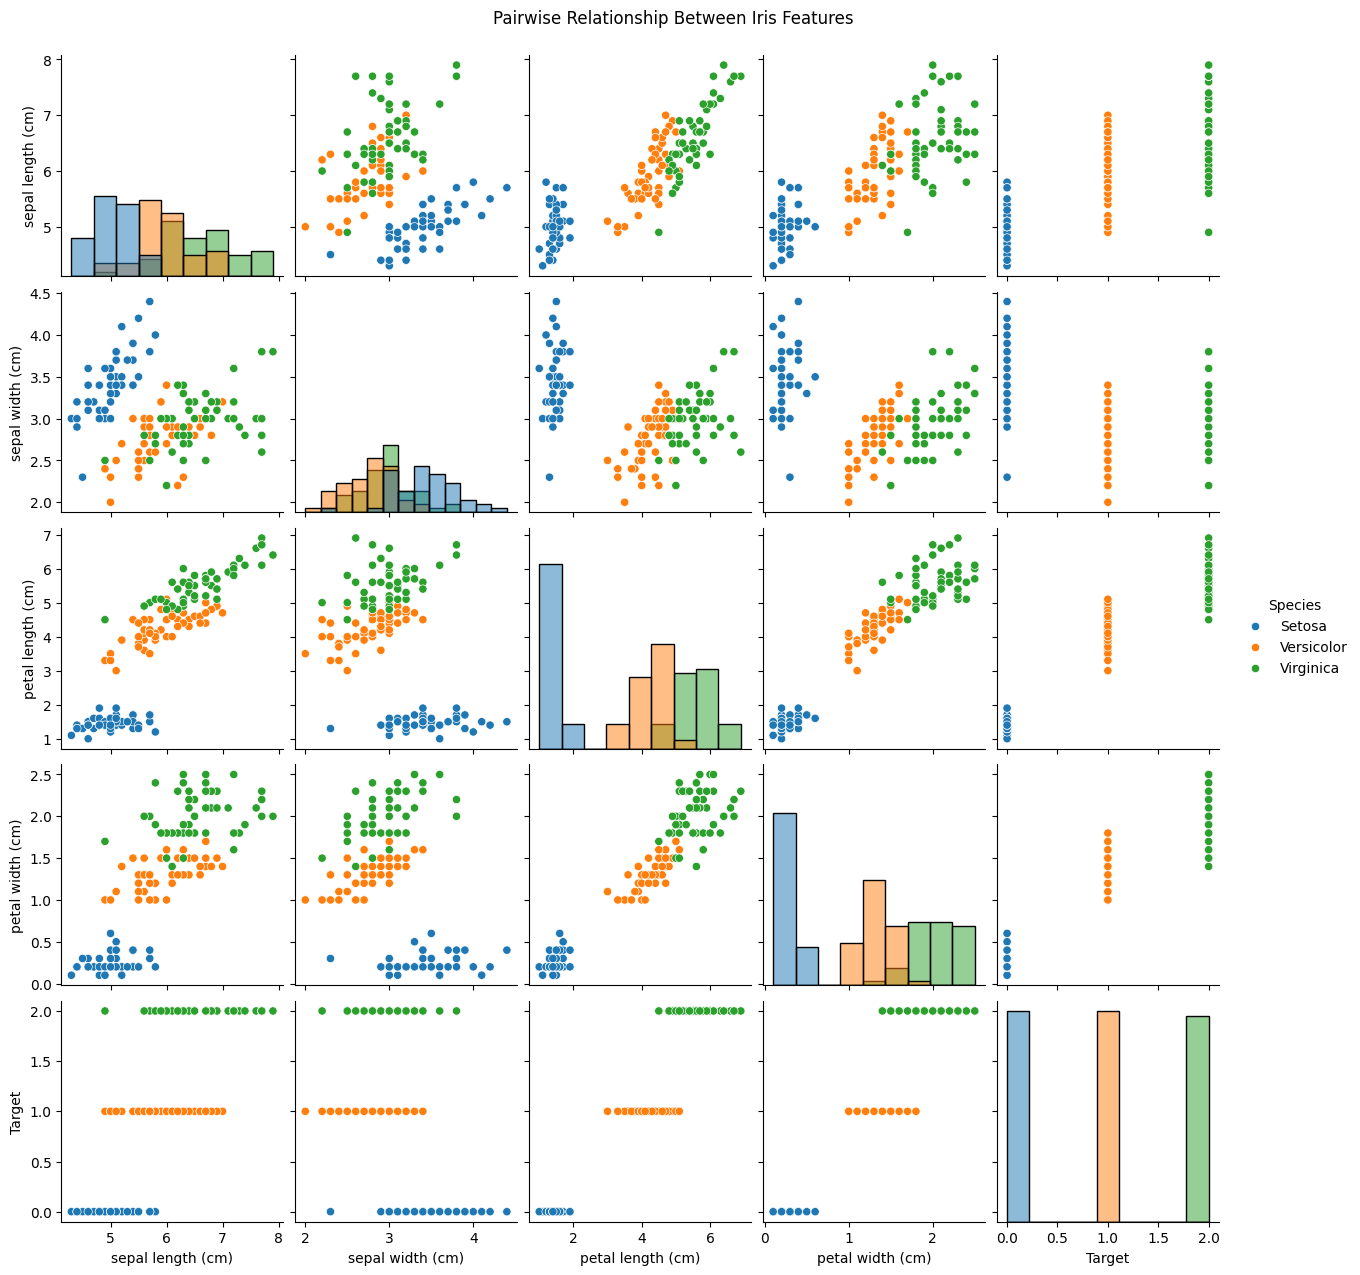


Correlation Matrix:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.118129           0.873738   
sepal width (cm)           -0.118129          1.000000          -0.426028   
petal length (cm)           0.873738         -0.426028           1.000000   
petal width (cm)            0.820620         -0.362894           0.962772   

                   petal width (cm)  
sepal length (cm)          0.820620  
sepal width (cm)          -0.362894  
petal length (cm)          0.962772  
petal width (cm)           1.000000  


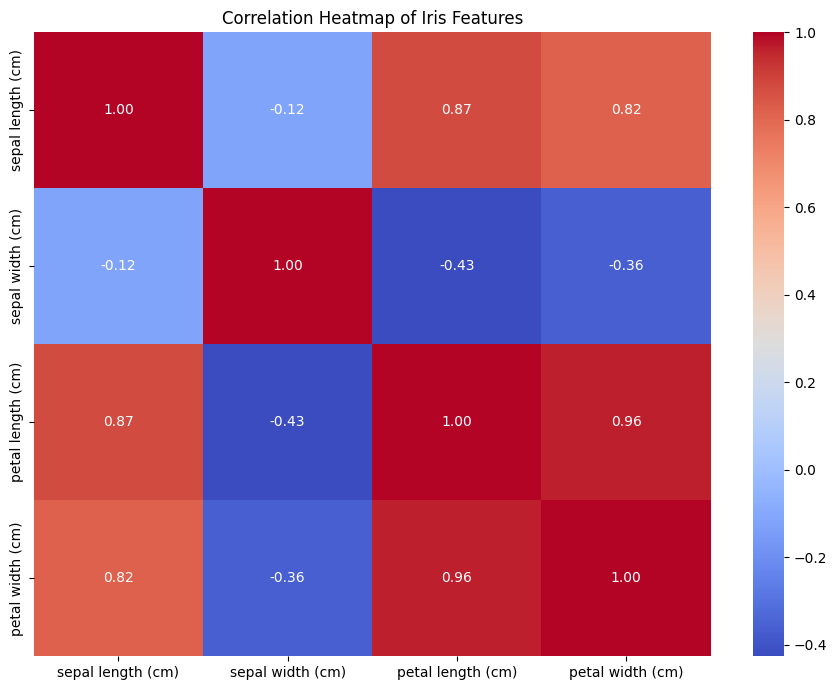


Species-wise Mean:
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
Species                                                              
Setosa               5.006000          3.428000           1.462000   
Versicolor           5.936000          2.770000           4.260000   
Virginica            6.604082          2.979592           5.561224   

            petal width (cm)  
Species                       
Setosa              0.246000  
Versicolor          1.326000  
Virginica           2.028571  


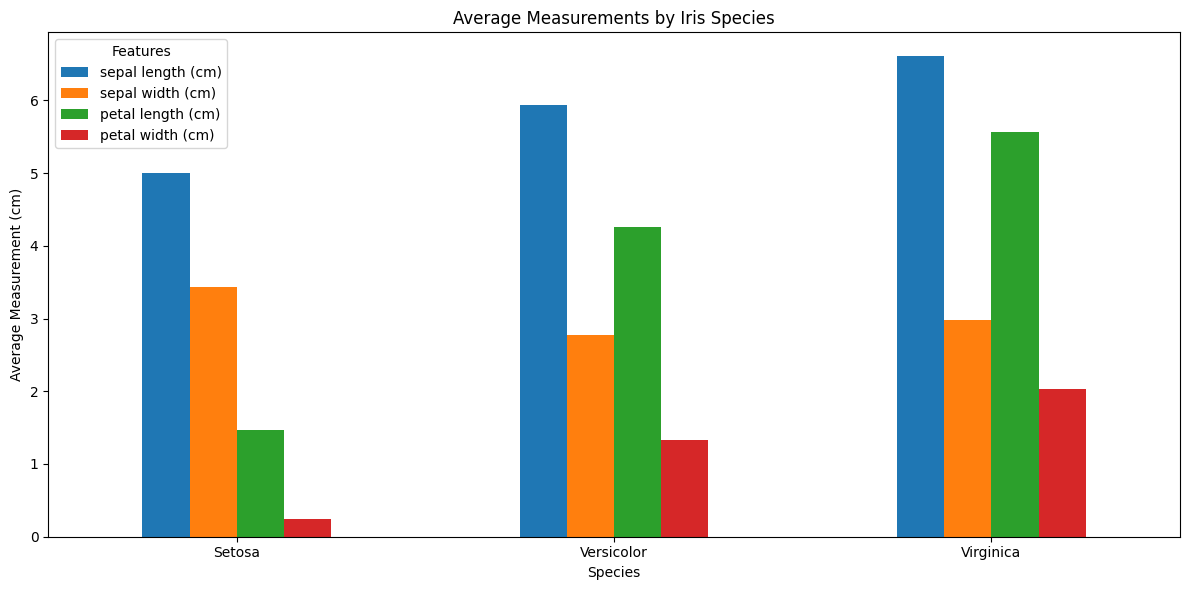


Feature Correlations:
petal length (cm)  petal width (cm)     0.962772
sepal length (cm)  petal length (cm)    0.873738
                   petal width (cm)     0.820620
                   sepal width (cm)    -0.118129
sepal width (cm)   petal width (cm)    -0.362894
                   petal length (cm)   -0.426028
dtype: float64

Strongest Positive Correlation:
0.962772294599787

Outlier Analysis:
sepal length (cm): 0 outliers
sepal width (cm): 4 outliers
petal length (cm): 0 outliers
petal width (cm): 0 outliers

Feature Ranges:
sepal length (cm): 3.60 cm
sepal width (cm): 2.40 cm
petal length (cm): 5.90 cm
petal width (cm): 2.40 cm

Analyzed Iris dataset saved successfully.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["Target"] = iris.target

df["Species"] = df["Target"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

print("First 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

df = df.drop_duplicates()

print("\nStatistical Summary:")
print(df.describe())

print("\nSpecies Distribution:")
print(df["Species"].value_counts())

numeric_columns = iris.feature_names

print("\nMean:")
print(df[numeric_columns].mean())

print("\nMedian:")
print(df[numeric_columns].median())

print("\nStandard Deviation:")
print(df[numeric_columns].std())

print("\nMinimum Values:")
print(df[numeric_columns].min())

print("\nMaximum Values:")
print(df[numeric_columns].max())

species_statistics = df.groupby("Species")[numeric_columns].agg(
    ["mean", "median", "min", "max", "std"]
)

print("\nSpecies-wise Statistics:")
print(species_statistics)

plt.figure(figsize=(8, 5))

df["Species"].value_counts().plot(
    kind="bar"
)

plt.title("Number of Flowers by Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 7))

df["Species"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Iris Species")
plt.ylabel("")
plt.show()

df[numeric_columns].hist(
    figsize=(12, 8),
    bins=15
)

plt.suptitle("Distribution of Iris Measurements")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df[numeric_columns]
)

plt.title("Boxplot of Iris Measurements")
plt.xlabel("Features")
plt.ylabel("Measurement")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

for column in numeric_columns:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="Species",
        y=column
    )

    plt.title(f"{column.title()} by Species")
    plt.xlabel("Species")
    plt.ylabel(column.title())
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="sepal length (cm)",
    y="sepal width (cm)",
    hue="Species",
    s=80
)

plt.title("Sepal Length vs Sepal Width")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="Species",
    s=80
)

plt.title("Petal Length vs Petal Width")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.tight_layout()
plt.show()

sns.pairplot(
    df,
    hue="Species",
    diag_kind="hist"
)

plt.suptitle(
    "Pairwise Relationship Between Iris Features",
    y=1.02
)

plt.show()

correlation = df[numeric_columns].corr()

print("\nCorrelation Matrix:")
print(correlation)

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Iris Features")
plt.tight_layout()
plt.show()

species_mean = df.groupby("Species")[numeric_columns].mean()

print("\nSpecies-wise Mean:")
print(species_mean)

species_mean.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Measurements by Iris Species")
plt.xlabel("Species")
plt.ylabel("Average Measurement (cm)")
plt.xticks(rotation=0)
plt.legend(title="Features")
plt.tight_layout()
plt.show()

correlation_matrix = df[numeric_columns].corr()

correlation_pairs = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(ascending=False)
)

print("\nFeature Correlations:")
print(correlation_pairs)

print("\nStrongest Positive Correlation:")
print(correlation_pairs.iloc[0])

print("\nOutlier Analysis:")

for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(
        f"{column}: {len(outliers)} outliers"
    )

print("\nFeature Ranges:")

for column in numeric_columns:

    feature_range = (
        df[column].max() -
        df[column].min()
    )

    print(
        f"{column}: {feature_range:.2f} cm"
    )

df.to_csv(
    "iris_analyzed.csv",
    index=False
)

print("\nAnalyzed Iris dataset saved successfully.")